In [15]:
import importlib
import WaveRegress
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
importlib.reload(WaveRegress)
%matplotlib inline

In [16]:
sim_datas, sim_targets = WaveRegress.generate_simulation(5000, seed=0)

In [17]:
test_datas, test_targets = WaveRegress.generate_simulation(1000, seed=1)

## 回归起始位置

training:   0%|          | 0/50 [00:00<?, ?it/s]

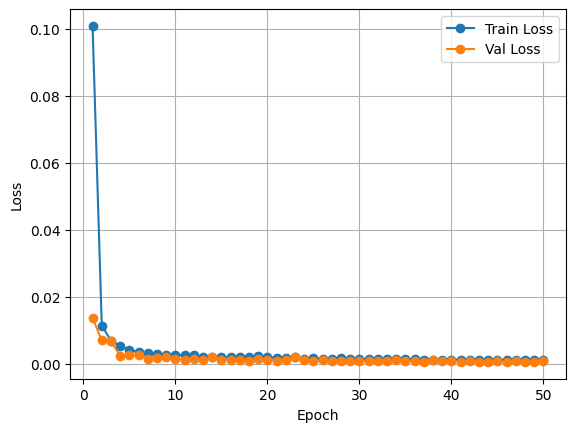

In [33]:
train_mission = WaveRegress.WaveRegress(data=sim_datas, target=sim_targets, output_param=[0, 0, 0, 0, 0, 1, 1])
train_mission.train(batch_size=32)

0.9985158558180245
0.9962577164779958


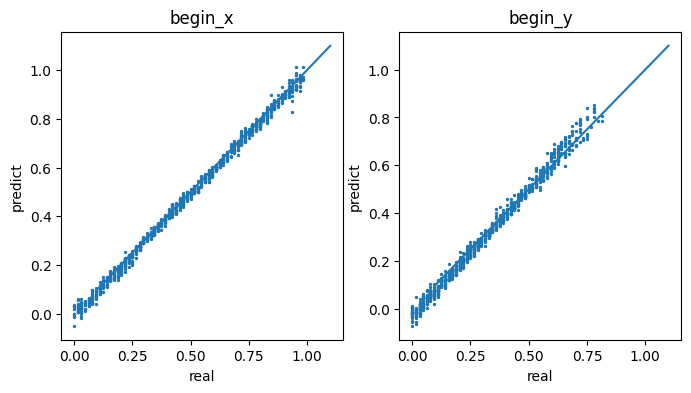

In [35]:
predict = train_mission.predict(test_datas)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
axs[0].scatter(test_targets[:, 5], predict[:, 0], s=2)
axs[0].plot(np.linspace(0.1, 1.1, 100), np.linspace(0.1, 1.1, 100))
axs[0].set_xlabel('real')
axs[0].set_ylabel('predict')
axs[0].set_title('begin_x')
axs[1].scatter(test_targets[:, 6], predict[:, 1], s=2)
axs[1].plot(np.linspace(0.1, 1.1, 100), np.linspace(0.1, 1.1, 100))
axs[1].set_xlabel('real')
axs[1].set_ylabel('predict')
axs[1].set_title('begin_y')
fig.savefig('./fig/begin_x&begin_y.png', dpi=300)
coe_x, p_x = stats.pearsonr(test_targets[:, 5], predict[:, 0])
coe_y, p_y = stats.pearsonr(test_targets[:, 6], predict[:, 1])
print(coe_x)
print(coe_y)

## 回归振幅

training:   0%|          | 0/50 [00:00<?, ?it/s]

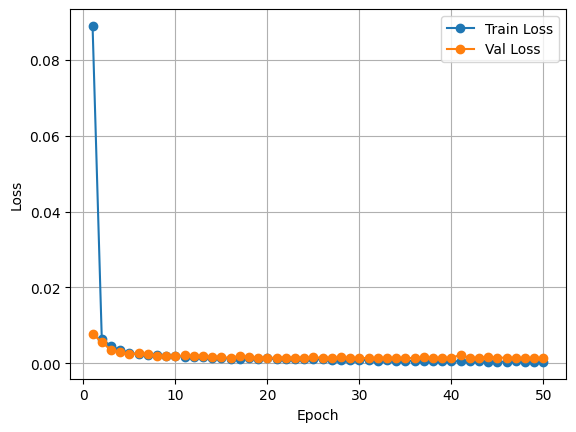

In [18]:
train_mission = WaveRegress.WaveRegress(data=sim_datas, target=sim_targets*16, output_param=[1, 0, 0, 0, 0, 0, 0])
train_mission.train(batch_size=32)

0.9055204074942164


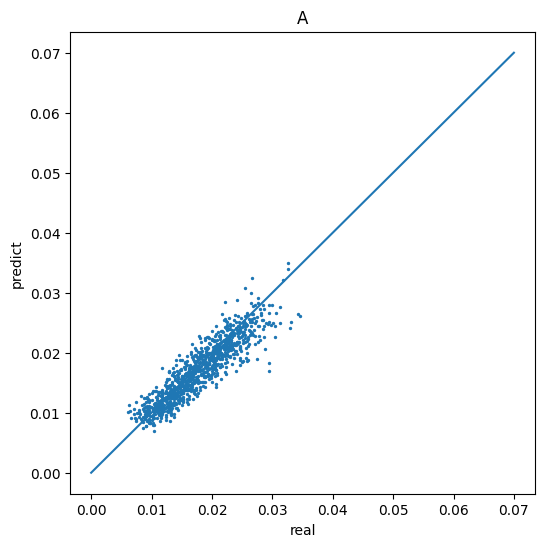

In [19]:
predict = train_mission.predict(test_datas)
fig, axs = plt.subplots(figsize=(6, 6))
axs.scatter(test_targets[:, 0], predict[:, 0]/16, s=2)
axs.plot(np.linspace(0, 0.07, 100), np.linspace(0, 0.07, 100))
axs.set_title('A')
axs.set_xlabel('real')
axs.set_ylabel('predict')
fig.savefig('./fig/A.png', dpi=300)
coe_A, p_A = stats.pearsonr(test_targets[:, 0], predict[:, 0])
print(coe_A)

## 回归周期

training:   0%|          | 0/50 [00:00<?, ?it/s]

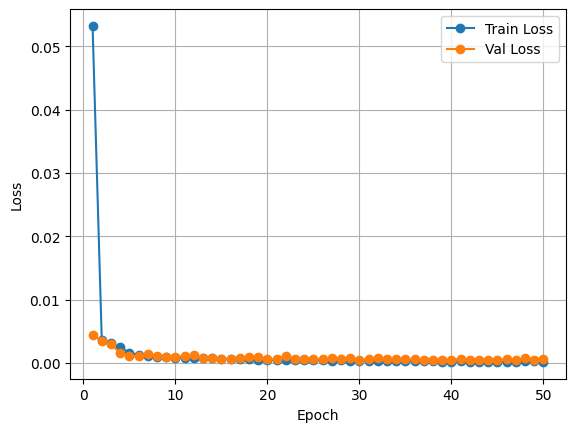

In [22]:
train_mission = WaveRegress.WaveRegress(data=sim_datas, target=sim_targets, output_param=[0, 1, 0, 0, 0, 0, 0])
train_mission.train(batch_size=32)

0.9140024718740566


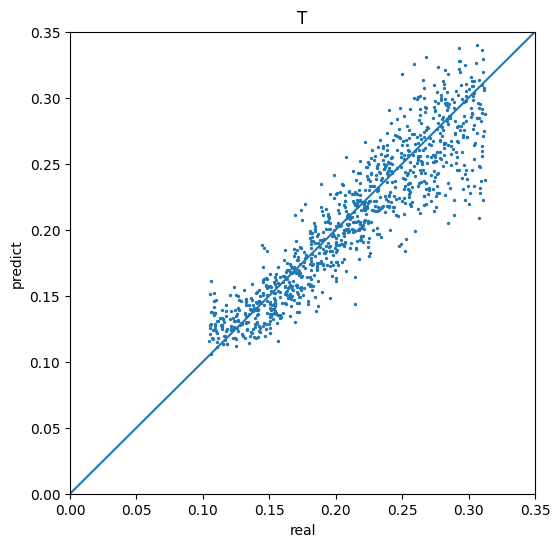

In [23]:
predict = train_mission.predict(test_datas)
fig, axs = plt.subplots(figsize=(6, 6))
axs.scatter(test_targets[:, 1], predict[:, 0], s=2)
axs.plot(np.linspace(0, 0.5, 100), np.linspace(0, 0.5, 100))
axs.set_xlim([0, 0.35])
axs.set_ylim([0, 0.35])
axs.set_title('T')
axs.set_xlabel('real')
axs.set_ylabel('predict')
fig.savefig('./fig/T.png', dpi=300)
coe_T, p_T = stats.pearsonr(test_targets[:, 1], predict[:, 0])
print(coe_T)

查看偏离正相关的点

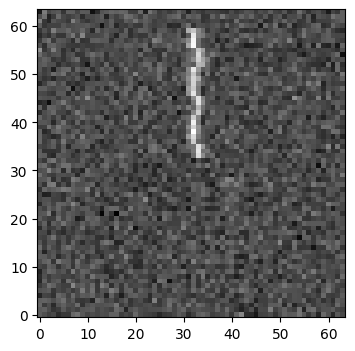

In [14]:
%matplotlib inline
e_index = np.where(np.abs(test_targets[:, 1]-predict[:, 0])>0.05)[0]
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(sim_datas[e_index[100]], cmap='gray', origin='lower')

## 回归寿命

training:   0%|          | 0/50 [00:00<?, ?it/s]

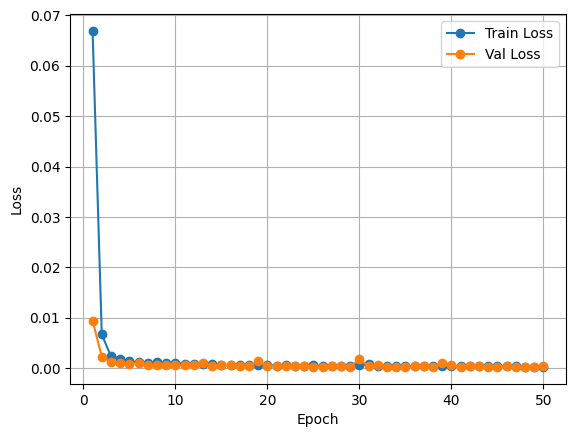

In [30]:
train_mission = WaveRegress.WaveRegress(data=sim_datas, target=sim_targets, output_param=[0, 0, 1, 0, 0, 0, 0])
train_mission.train(batch_size=32)

0.9907309643319786


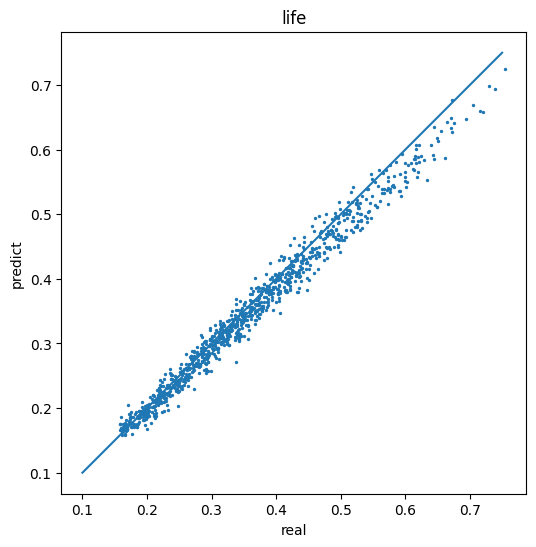

In [32]:
predict = train_mission.predict(test_datas)
fig, axs = plt.subplots(figsize=(6, 6))
axs.scatter(test_targets[:, 2], predict[:, 0], s=2)
axs.plot(np.linspace(0.1, 0.75, 100), np.linspace(0.1, 0.75, 100))
axs.set_title('life')
axs.set_xlabel('real')
axs.set_ylabel('predict')
fig.savefig('./fig/life.png', dpi=300)
coe_life, p_life = stats.pearsonr(test_targets[:, 2], predict[:, 0])
print(coe_life)

## 回归相位

In [ ]:
train_mission = WaveRegress.WaveRegress(data=sim_datas, target=sim_targets, output_param=[0, 0, 0, 1, 1, 0, 0])
train_mission.train(batch_size=32)

In [ ]:
predict = train_mission.predict(sim_datas)
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(6, 3))
axs[0].scatter(sim_targets[:, 3], predict[:, 0])
axs[1].scatter(sim_targets[:, 4], predict[:, 1])

## 从标记好的波动中提取波动信息

In [ ]:
def wave_info(data, label, threshold=0.8):
    boxes = label['boxes'].cpu().numpy()
    scores = label['scores'].cpu().numpy()
    num = np.sum(scores>threshold)
    waves = np.zeros((num, 64, 64))

    for i, (box, score) in enumerate(zip(boxes, scores)):
        if score < threshold:
            continue
        x_min, y_min, x_max, y_max = box.astype(int)
        width = x_max - x_min
        height = y_max - y_min
        begin_x = 32-width//2
        begin_y = 32-height//2
        waves[i, begin_y:begin_y+height+1, begin_x:begin_x+width+1] = data[y_min:y_max+1, x_min:x_max+1]

    predict_mission = WaveRegress.WaveRegress(data=None, output_param=[1, 1, 0, 0, 0, 1], load_path="./pytorch/Wave_Regress_Model.pth")
    predict = predict_mission.predict(waves)
    return predict

In [ ]:
data = np.load('../data/st_phasecong.npy')
label = np.load('../data/wave_label_predict.npy', allow_pickle=True).tolist()

predict = wave_info(data, label)

In [ ]:
plt.hist(predict[:, 2]*64*3)
plt.title('life')
plt.xlabel('life/s')
plt.show()
plt.savefig('../fig/life_predict.png', dpi=300)